In [1]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             52 bits physical, 57 bits virtual
  Byte Order:                Little Endian
CPU(s):                      192
  On-line CPU(s) list:       0-191
Vendor ID:                   AuthenticAMD
  Model name:                AMD EPYC 9684X 96-Core Processor
    CPU family:              25
    Model:                   17
    Thread(s) per core:      1
    Core(s) per socket:      96
    Socket(s):               2
    Stepping:                2
    Frequency boost:         enabled
    CPU(s) scaling MHz:      69%
    CPU max MHz:             3715.4290
    CPU min MHz:             1500.0000
    BogoMIPS:                5099.89
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ht s
                             yscall nx mmxext fxsr_opt pdpe1gb rdtscp lm constan
                         

In [2]:
import numpy as np
import pickle
import time
import glob

import sys
sys.path.insert(0, "../..")
from shared import load_sweep_data, run_param_recovery, plot_param_estimate, setup_latex_matplotlib

In [3]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=r"delta_grad == 0\.0\. Check if the approximated function is linear\..*",
    category=UserWarning,
)

In [4]:
all_data, data_keys = load_sweep_data("a")

Loaded 11 a values from addm_data_all_a_20260222-212154.pkl


In [5]:
num_data_list = [100, 200, 400, 800, 1600, 3200, 6400, 12800, 25600]

### Run maximum likelihood with aDDM likelihood function with different dataset size

In [6]:
paras_true, paras_mle = run_param_recovery(all_data, num_data_list, mode="mle")

true params: [0.30, 0.50, 1.50, 0.50]


num_data:   100, mle: [0.19298, 0.57477, 1.57468, 0.51972]
num_data:   200, mle: [0.27397, 0.56210, 1.54486, 0.52324]
num_data:   400, mle: [0.30120, 0.54913, 1.51984, 0.54041]
num_data:   800, mle: [0.27259, 0.52221, 1.51671, 0.53145]
num_data:  1600, mle: [0.28796, 0.50969, 1.51114, 0.51150]
num_data:  3200, mle: [0.28870, 0.50475, 1.51013, 0.49982]
num_data:  6400, mle: [0.29503, 0.50073, 1.49794, 0.51163]
num_data: 12800, mle: [0.29339, 0.49946, 1.49595, 0.49735]
num_data: 25600, mle: [0.29381, 0.49853, 1.50355, 0.50117]

true params: [0.30, 0.50, 1.60, 0.50]
num_data:   100, mle: [0.20610, 0.51010, 1.65002, 0.56334]
num_data:   200, mle: [0.24655, 0.45290, 1.56295, 0.53504]
num_data:   400, mle: [0.25776, 0.45990, 1.58773, 0.55123]
num_data:   800, mle: [0.27204, 0.49719, 1.60115, 0.52646]
num_data:  1600, mle: [0.28331, 0.50575, 1.60891, 0.52061]
num_data:  3200, mle: [0.29142, 0.50981, 1.59489, 0.49323]
num_data:  6400, mle: [0.29992, 0.50825, 1.60589, 0.50586]
num_data: 12800, 

### Run maximum likelihood with TADA likelihood function with different dataset size

In [7]:
_, paras_tada = run_param_recovery(all_data, num_data_list, mode="tada")

true params: [0.30, 0.50, 1.50, 0.50]
num_data:   100, tada mle: [0.02712, 0.67016, 1.55524, 0.47841]
num_data:   200, tada mle: [0.07900, 0.67845, 1.55269, 0.51215]
num_data:   400, tada mle: [0.14216, 0.62900, 1.50973, 0.50633]
num_data:   800, tada mle: [0.12158, 0.59224, 1.50383, 0.49663]
num_data:  1600, tada mle: [0.13980, 0.57654, 1.49919, 0.48703]
num_data:  3200, tada mle: [0.12932, 0.57705, 1.50212, 0.47776]
num_data:  6400, tada mle: [0.13892, 0.56684, 1.48722, 0.48749]
num_data: 12800, tada mle: [0.13945, 0.56529, 1.48407, 0.47418]
num_data: 25600, tada mle: [0.13872, 0.56420, 1.49227, 0.47803]

true params: [0.30, 0.50, 1.60, 0.50]
num_data:   100, tada mle: [0.27615, 0.46388, 1.58372, 0.51246]
num_data:   200, tada mle: [0.18230, 0.46529, 1.52544, 0.49794]
num_data:   400, tada mle: [0.08887, 0.51814, 1.56460, 0.51915]
num_data:   800, tada mle: [0.10589, 0.56399, 1.58738, 0.50139]
num_data:  1600, tada mle: [0.11952, 0.57272, 1.59603, 0.49572]
num_data:  3200, tada mle: 

num_data: 25600, tada mle: [0.19449, 0.54159, 2.26598, 0.47465]

true params: [0.30, 0.50, 2.40, 0.50]
num_data:   100, tada mle: [0.15800, 0.60189, 2.44633, 0.52131]
num_data:   200, tada mle: [0.20902, 0.55425, 2.44196, 0.52112]
num_data:   400, tada mle: [0.25770, 0.51666, 2.46492, 0.54457]
num_data:   800, tada mle: [0.20933, 0.52784, 2.40673, 0.49978]
num_data:  1600, tada mle: [0.17592, 0.52442, 2.32941, 0.47059]
num_data:  3200, tada mle: [0.19570, 0.54150, 2.36977, 0.48295]
num_data:  6400, tada mle: [0.20540, 0.54539, 2.37801, 0.49336]
num_data: 12800, tada mle: [0.19577, 0.54367, 2.36646, 0.48718]
num_data: 25600, tada mle: [0.19489, 0.54366, 2.37072, 0.48814]

true params: [0.30, 0.50, 2.50, 0.50]
num_data:   100, tada mle: [0.27796, 0.59956, 2.41758, 0.53367]
num_data:   200, tada mle: [0.21890, 0.60423, 2.45067, 0.56614]
num_data:   400, tada mle: [0.20410, 0.54034, 2.45100, 0.54689]
num_data:   800, tada mle: [0.16287, 0.56234, 2.48296, 0.51366]
num_data:  1600, tada mle:

In [8]:
# data_to_save = {
#     "paras_true_arr": paras_true,
#     "paras_mle_arr": paras_mle,
#     "paras_tada_arr": paras_tada,
# }
# fname = "tada_mle_result_" + time.strftime("%Y%m%d-%H%M%S") + ".pkl"
# with open(fname, "wb") as f:
#     pickle.dump(data_to_save, f)
# print(f"Saved to {fname}")

In [9]:
# # load results (if necessary)
# result_files = sorted(glob.glob("tada_mle_result_*.pkl"))
# results = pickle.load(open(result_files[-1], "rb"))
# paras_true = results["paras_true_arr"]
# paras_mle = results["paras_mle_arr"]
# paras_tada = results["paras_tada_arr"]

In [10]:
setup_latex_matplotlib()

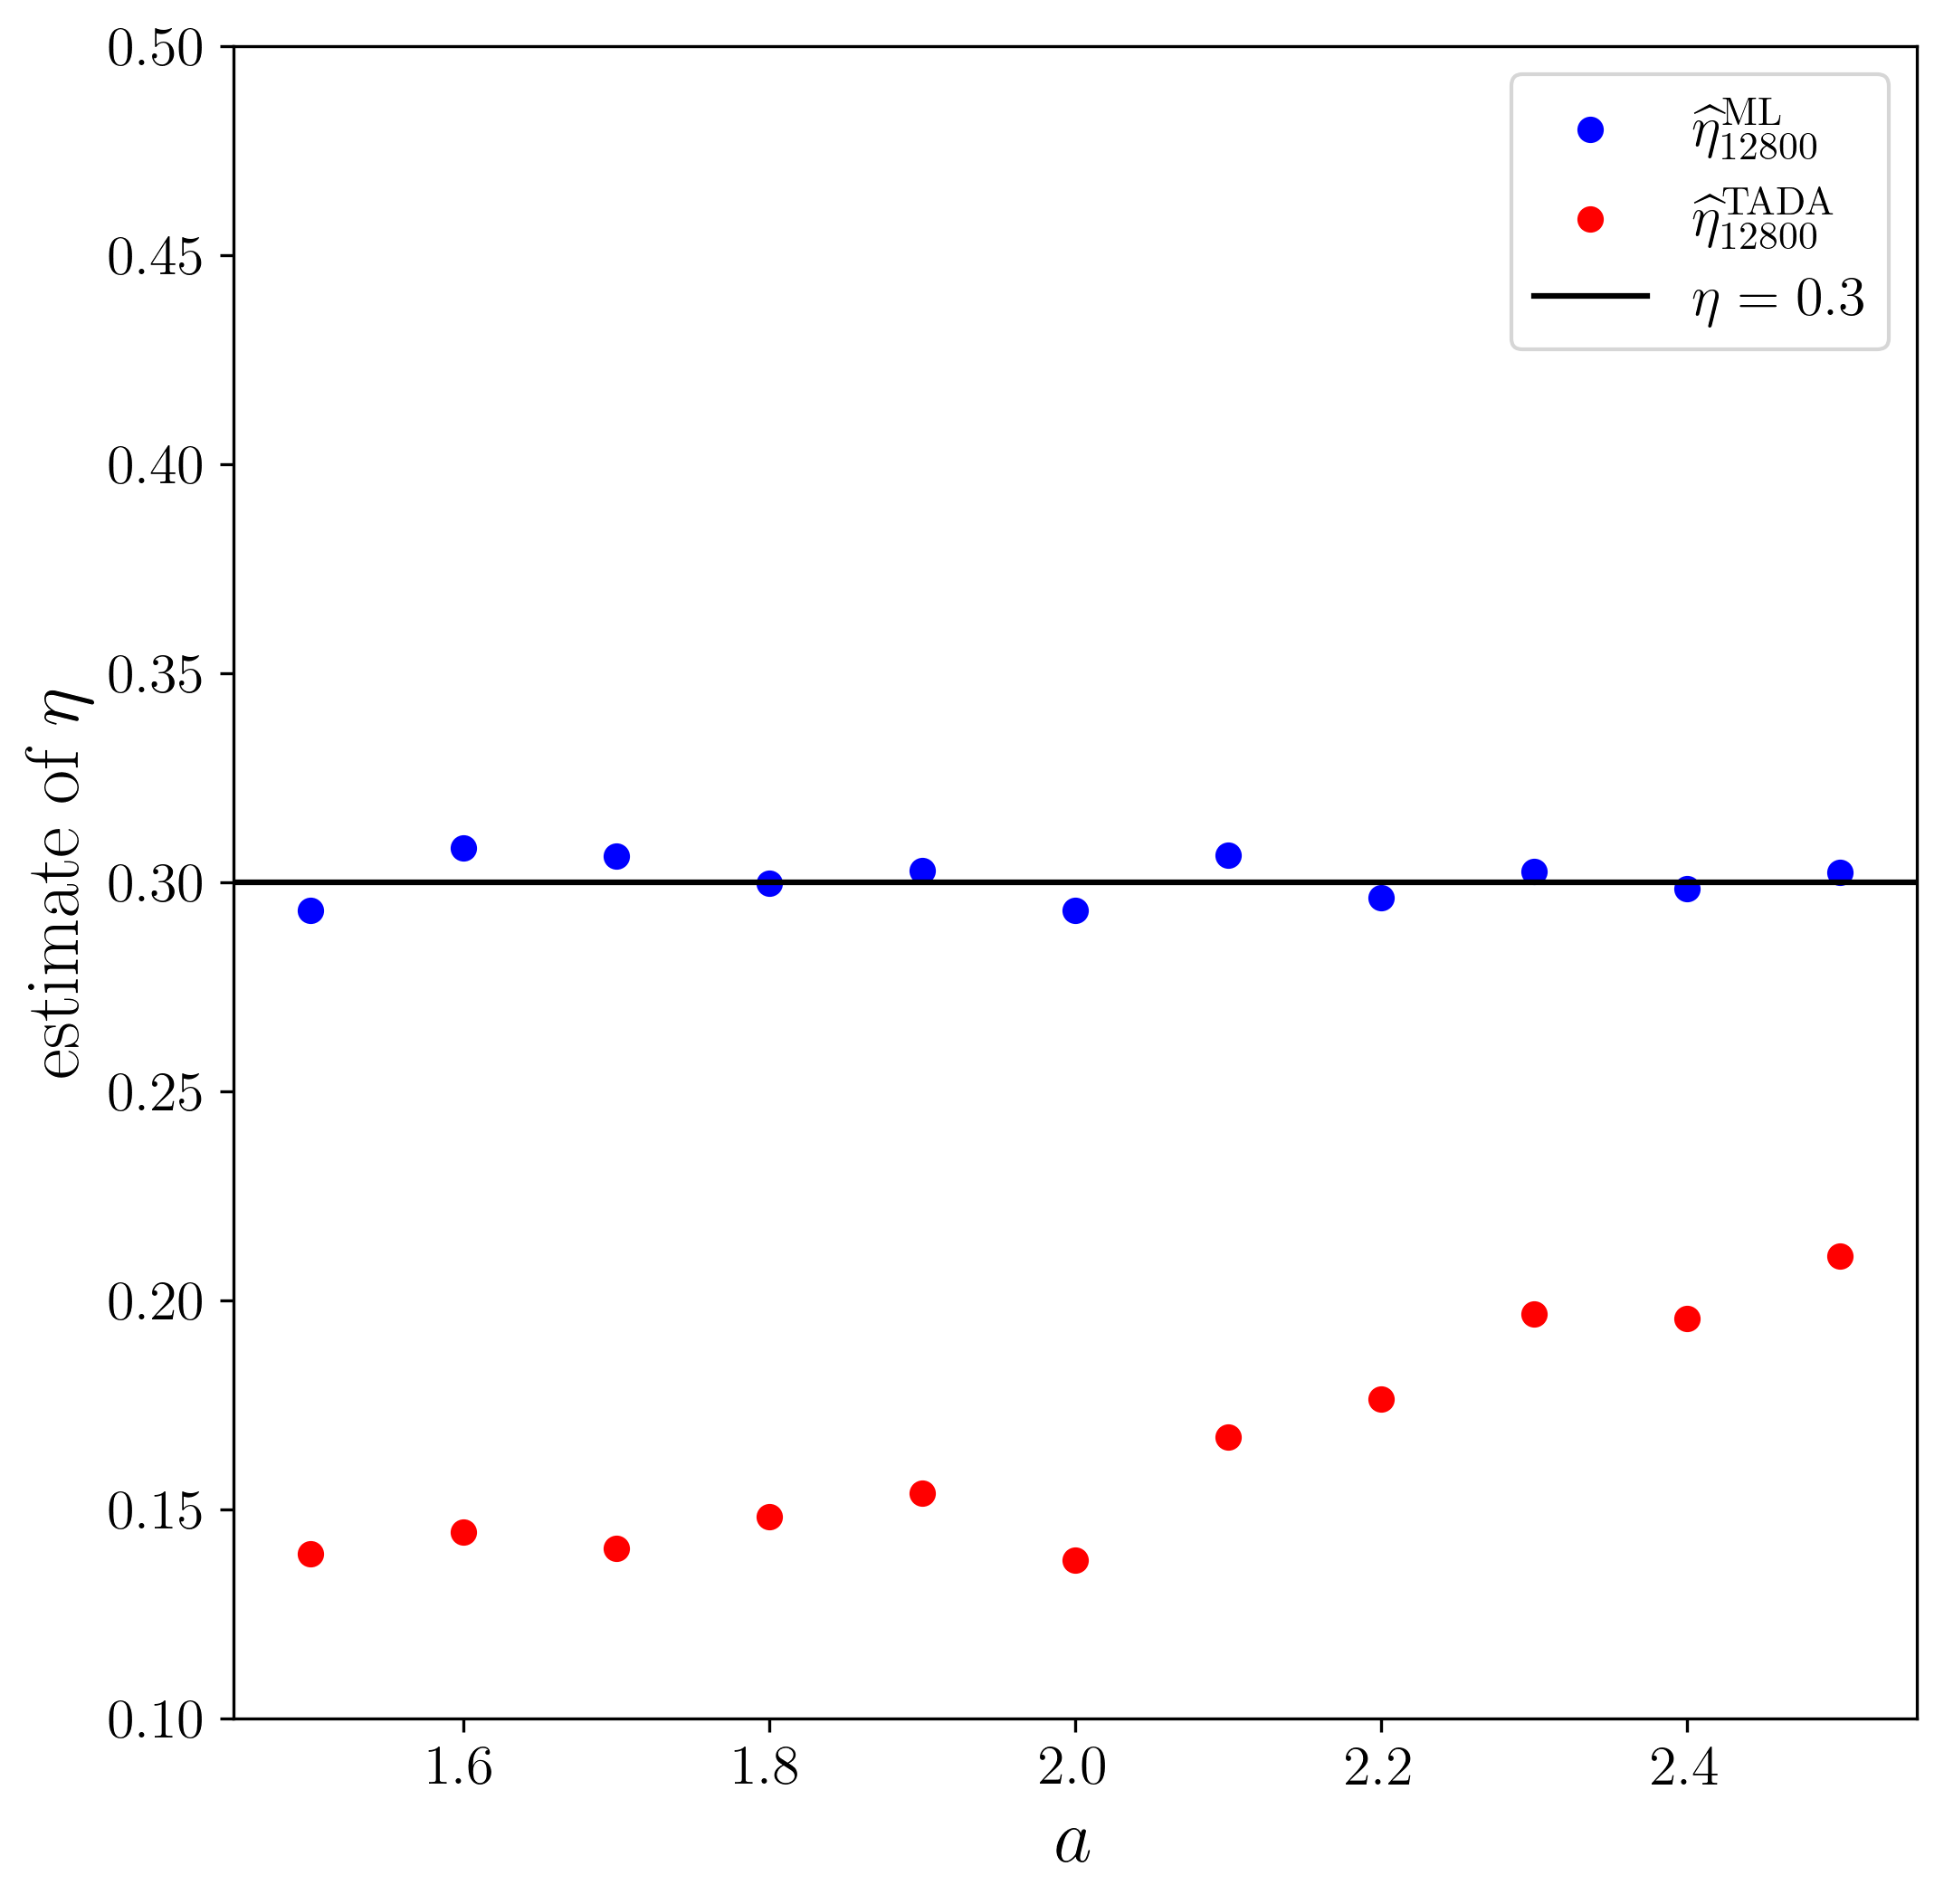

In [11]:
plot_param_estimate(
    paras_true, paras_mle, paras_tada,
    param_idx=0, param_name=r"\eta",
    swept_idx=2, swept_name=r"a",
    num_data_list=num_data_list,
    horizontal_line=paras_true[-2, 0, 0],
    xlim=(1.45, 2.55), ylim=(0.1, 0.5),
)

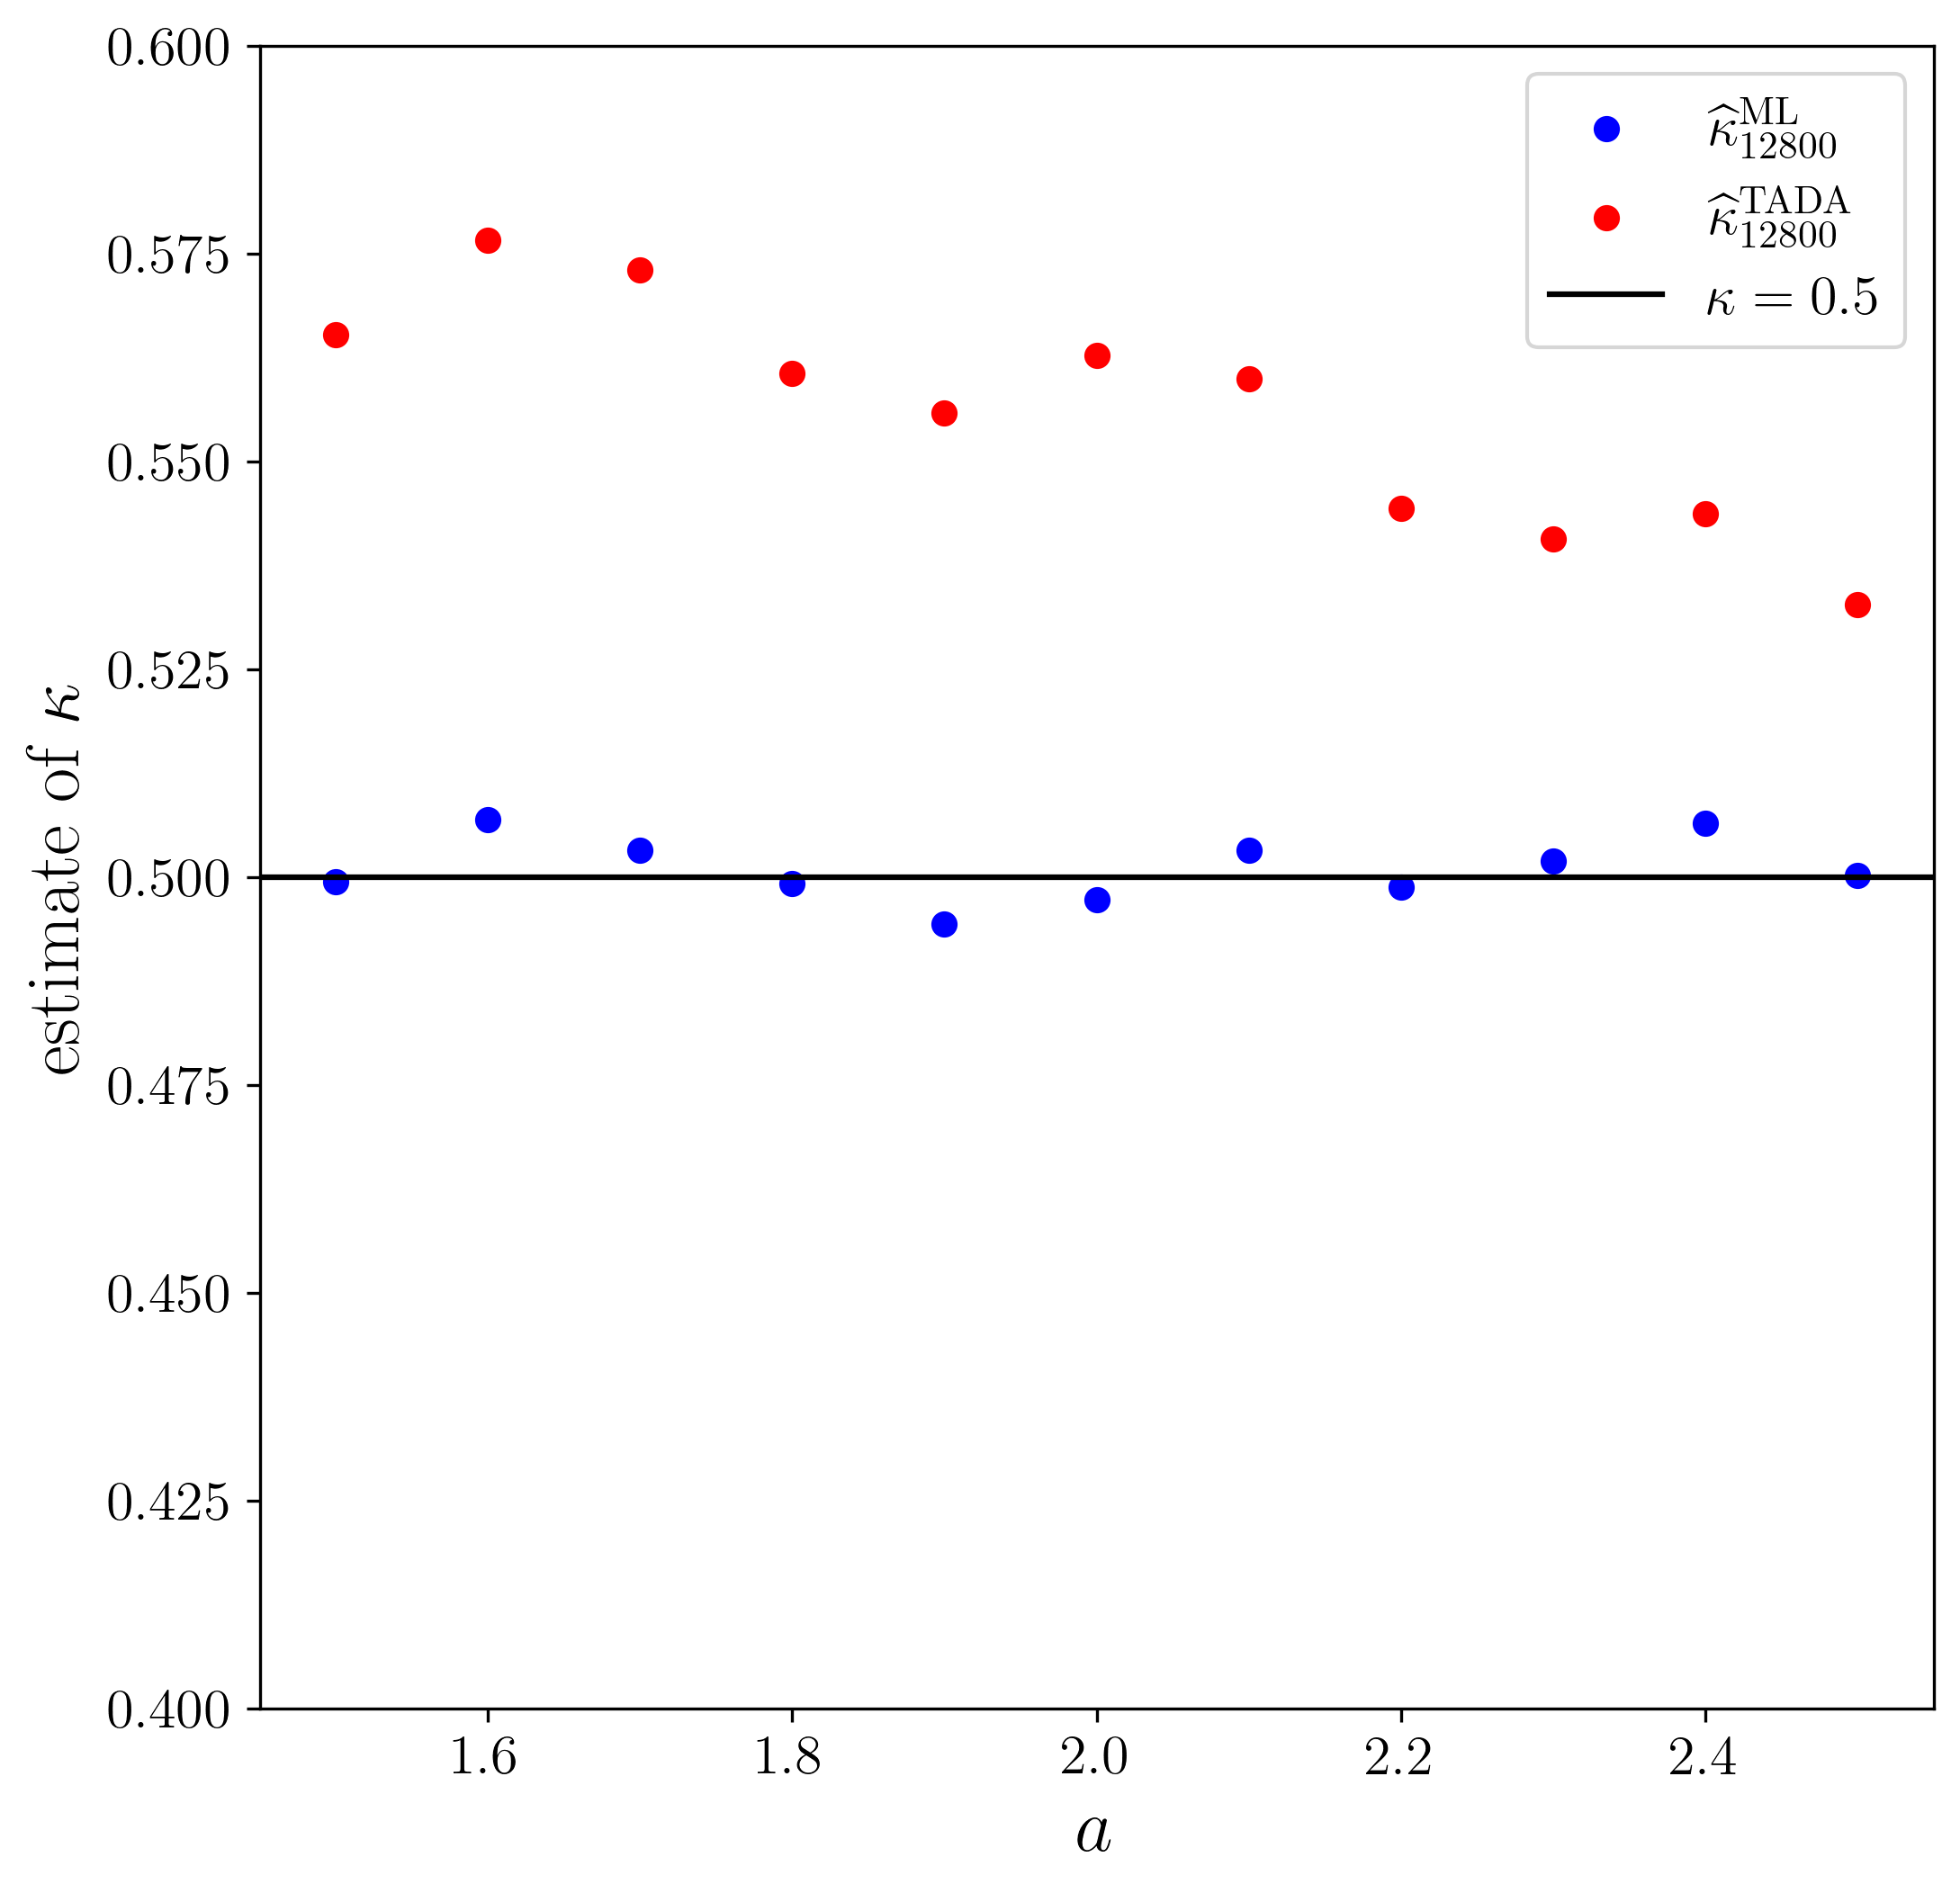

In [12]:
plot_param_estimate(
    paras_true, paras_mle, paras_tada,
    param_idx=1, param_name=r"\kappa",
    swept_idx=2, swept_name=r"a",
    num_data_list=num_data_list,
    horizontal_line=paras_true[-2, 0, 1],
    xlim=(1.45, 2.55), ylim=(0.4, 0.6),
)

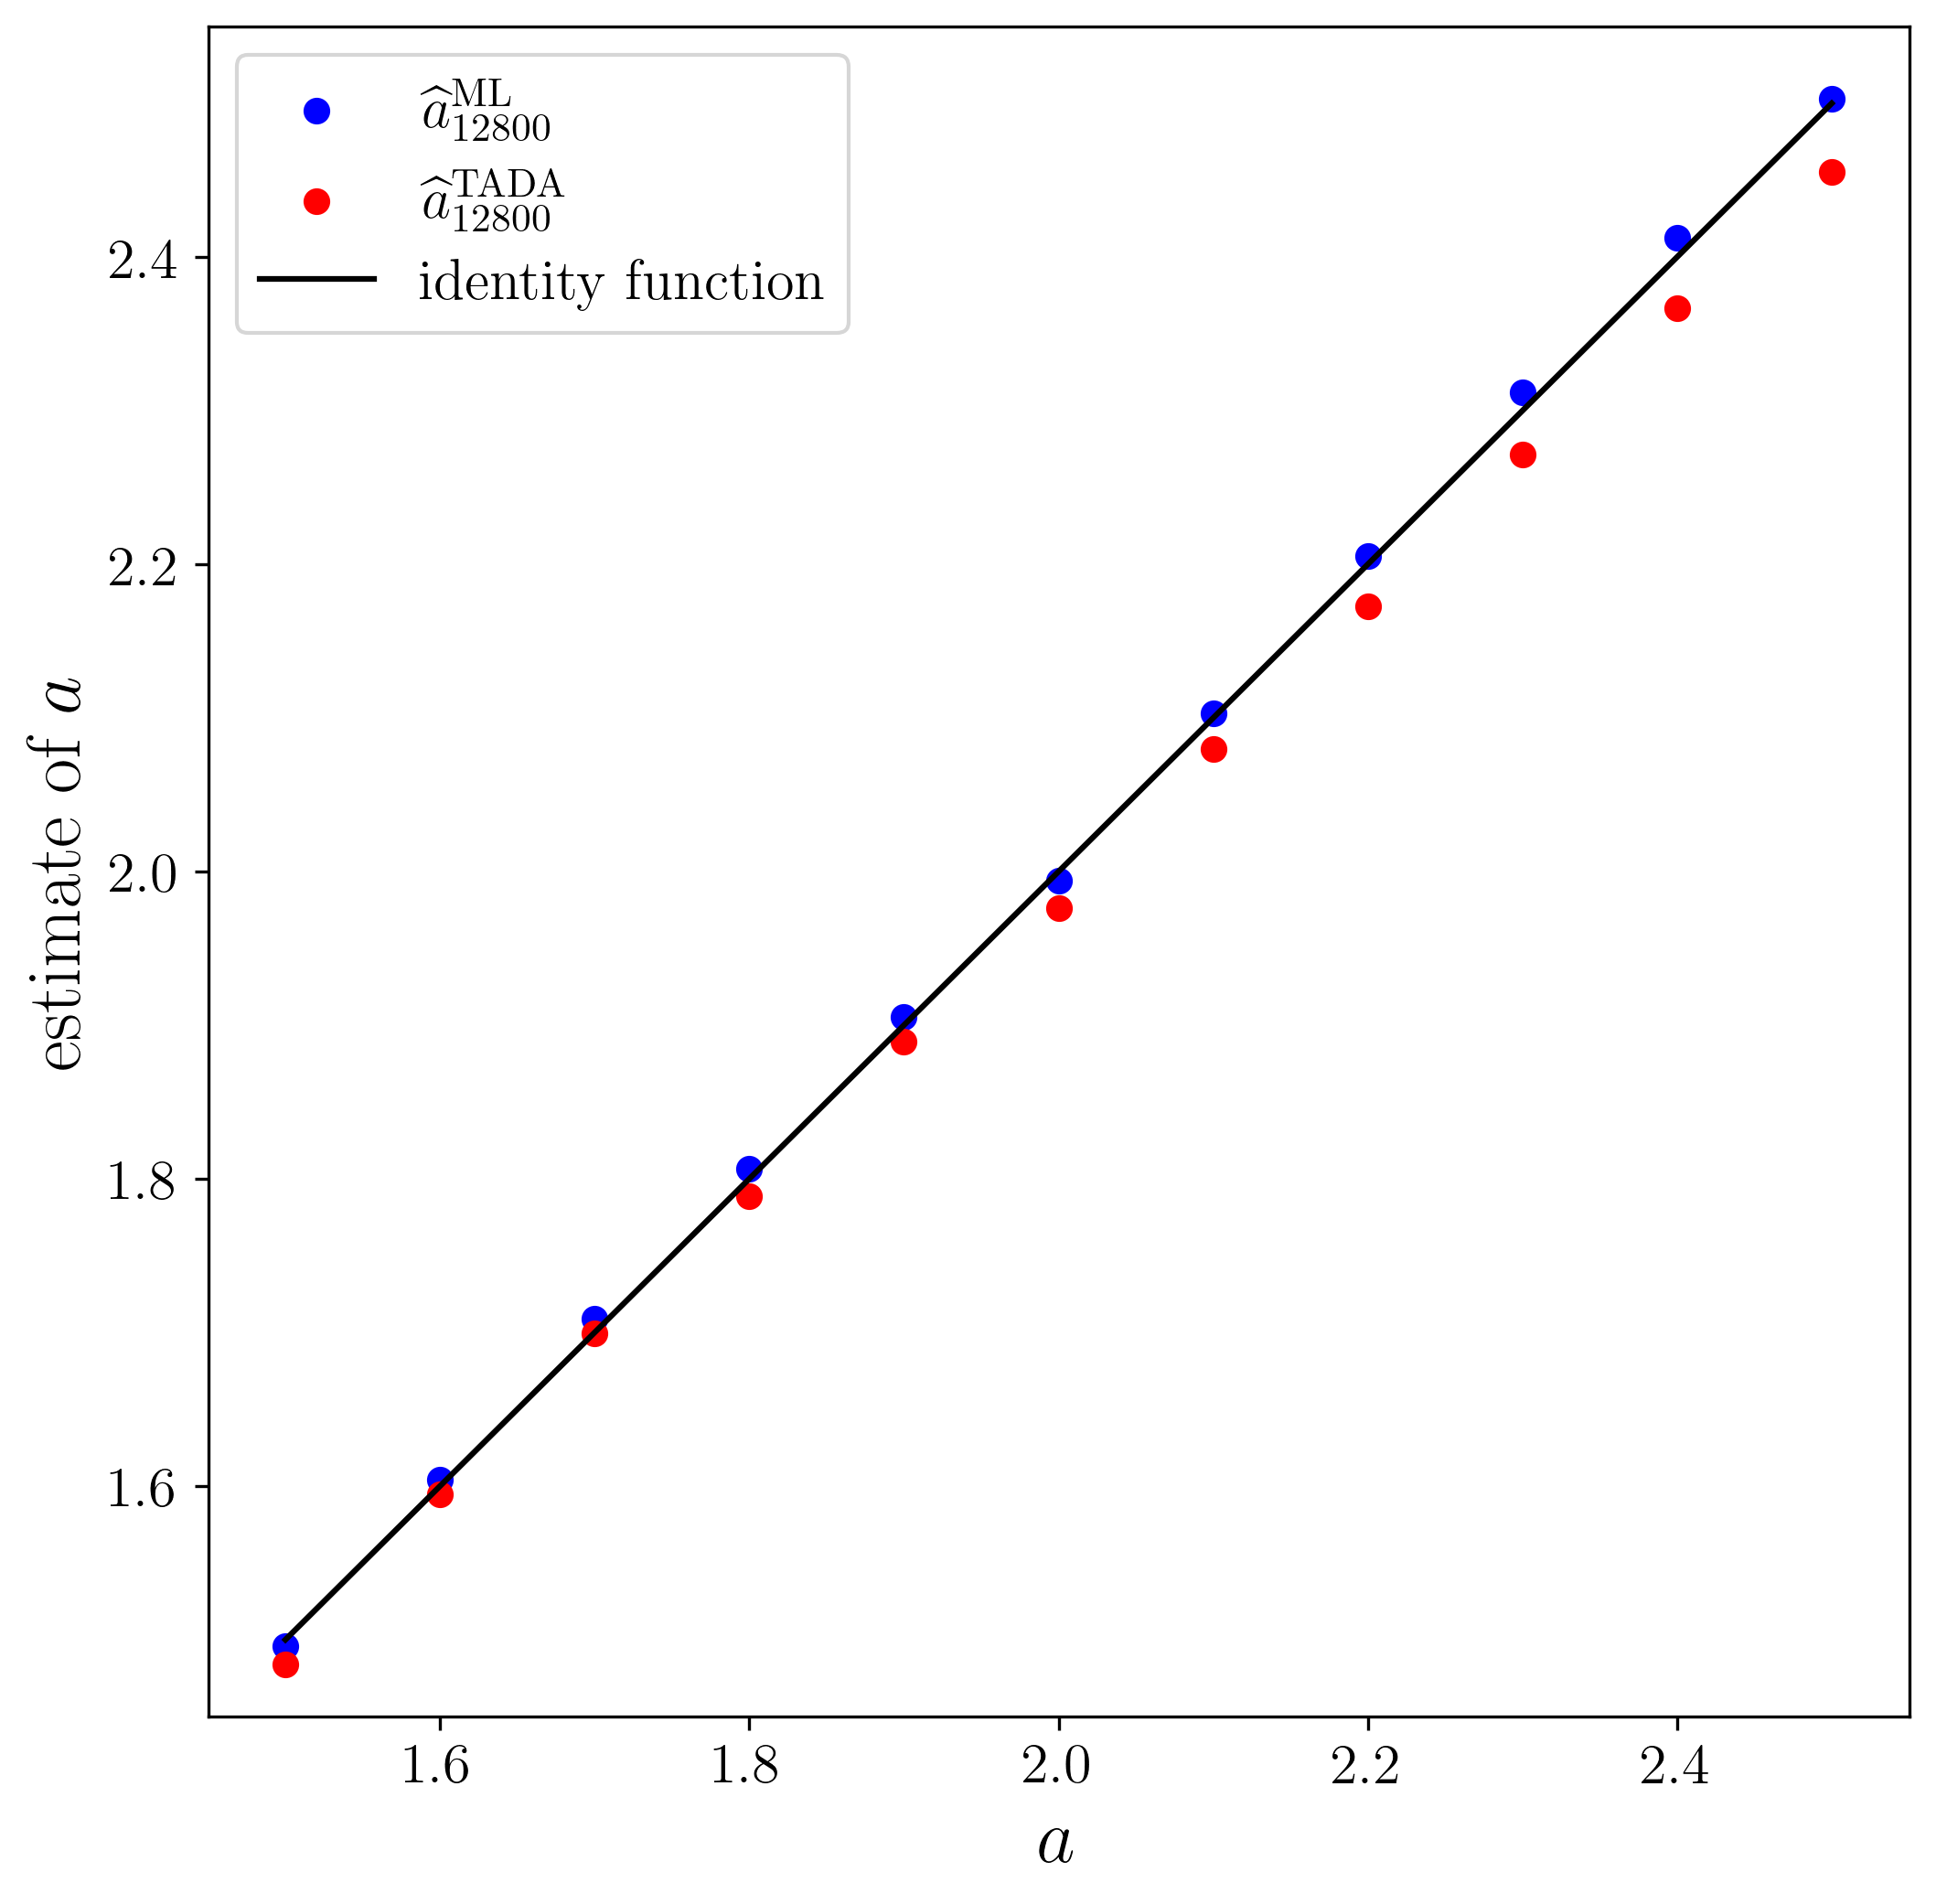

In [13]:
plot_param_estimate(
    paras_true, paras_mle, paras_tada,
    param_idx=2, param_name=r"a",
    swept_idx=2, swept_name=r"a",
    num_data_list=num_data_list,
    identity_line=True,
    xlim=(1.45, 2.55), ylim=(1.45, 2.55),
)

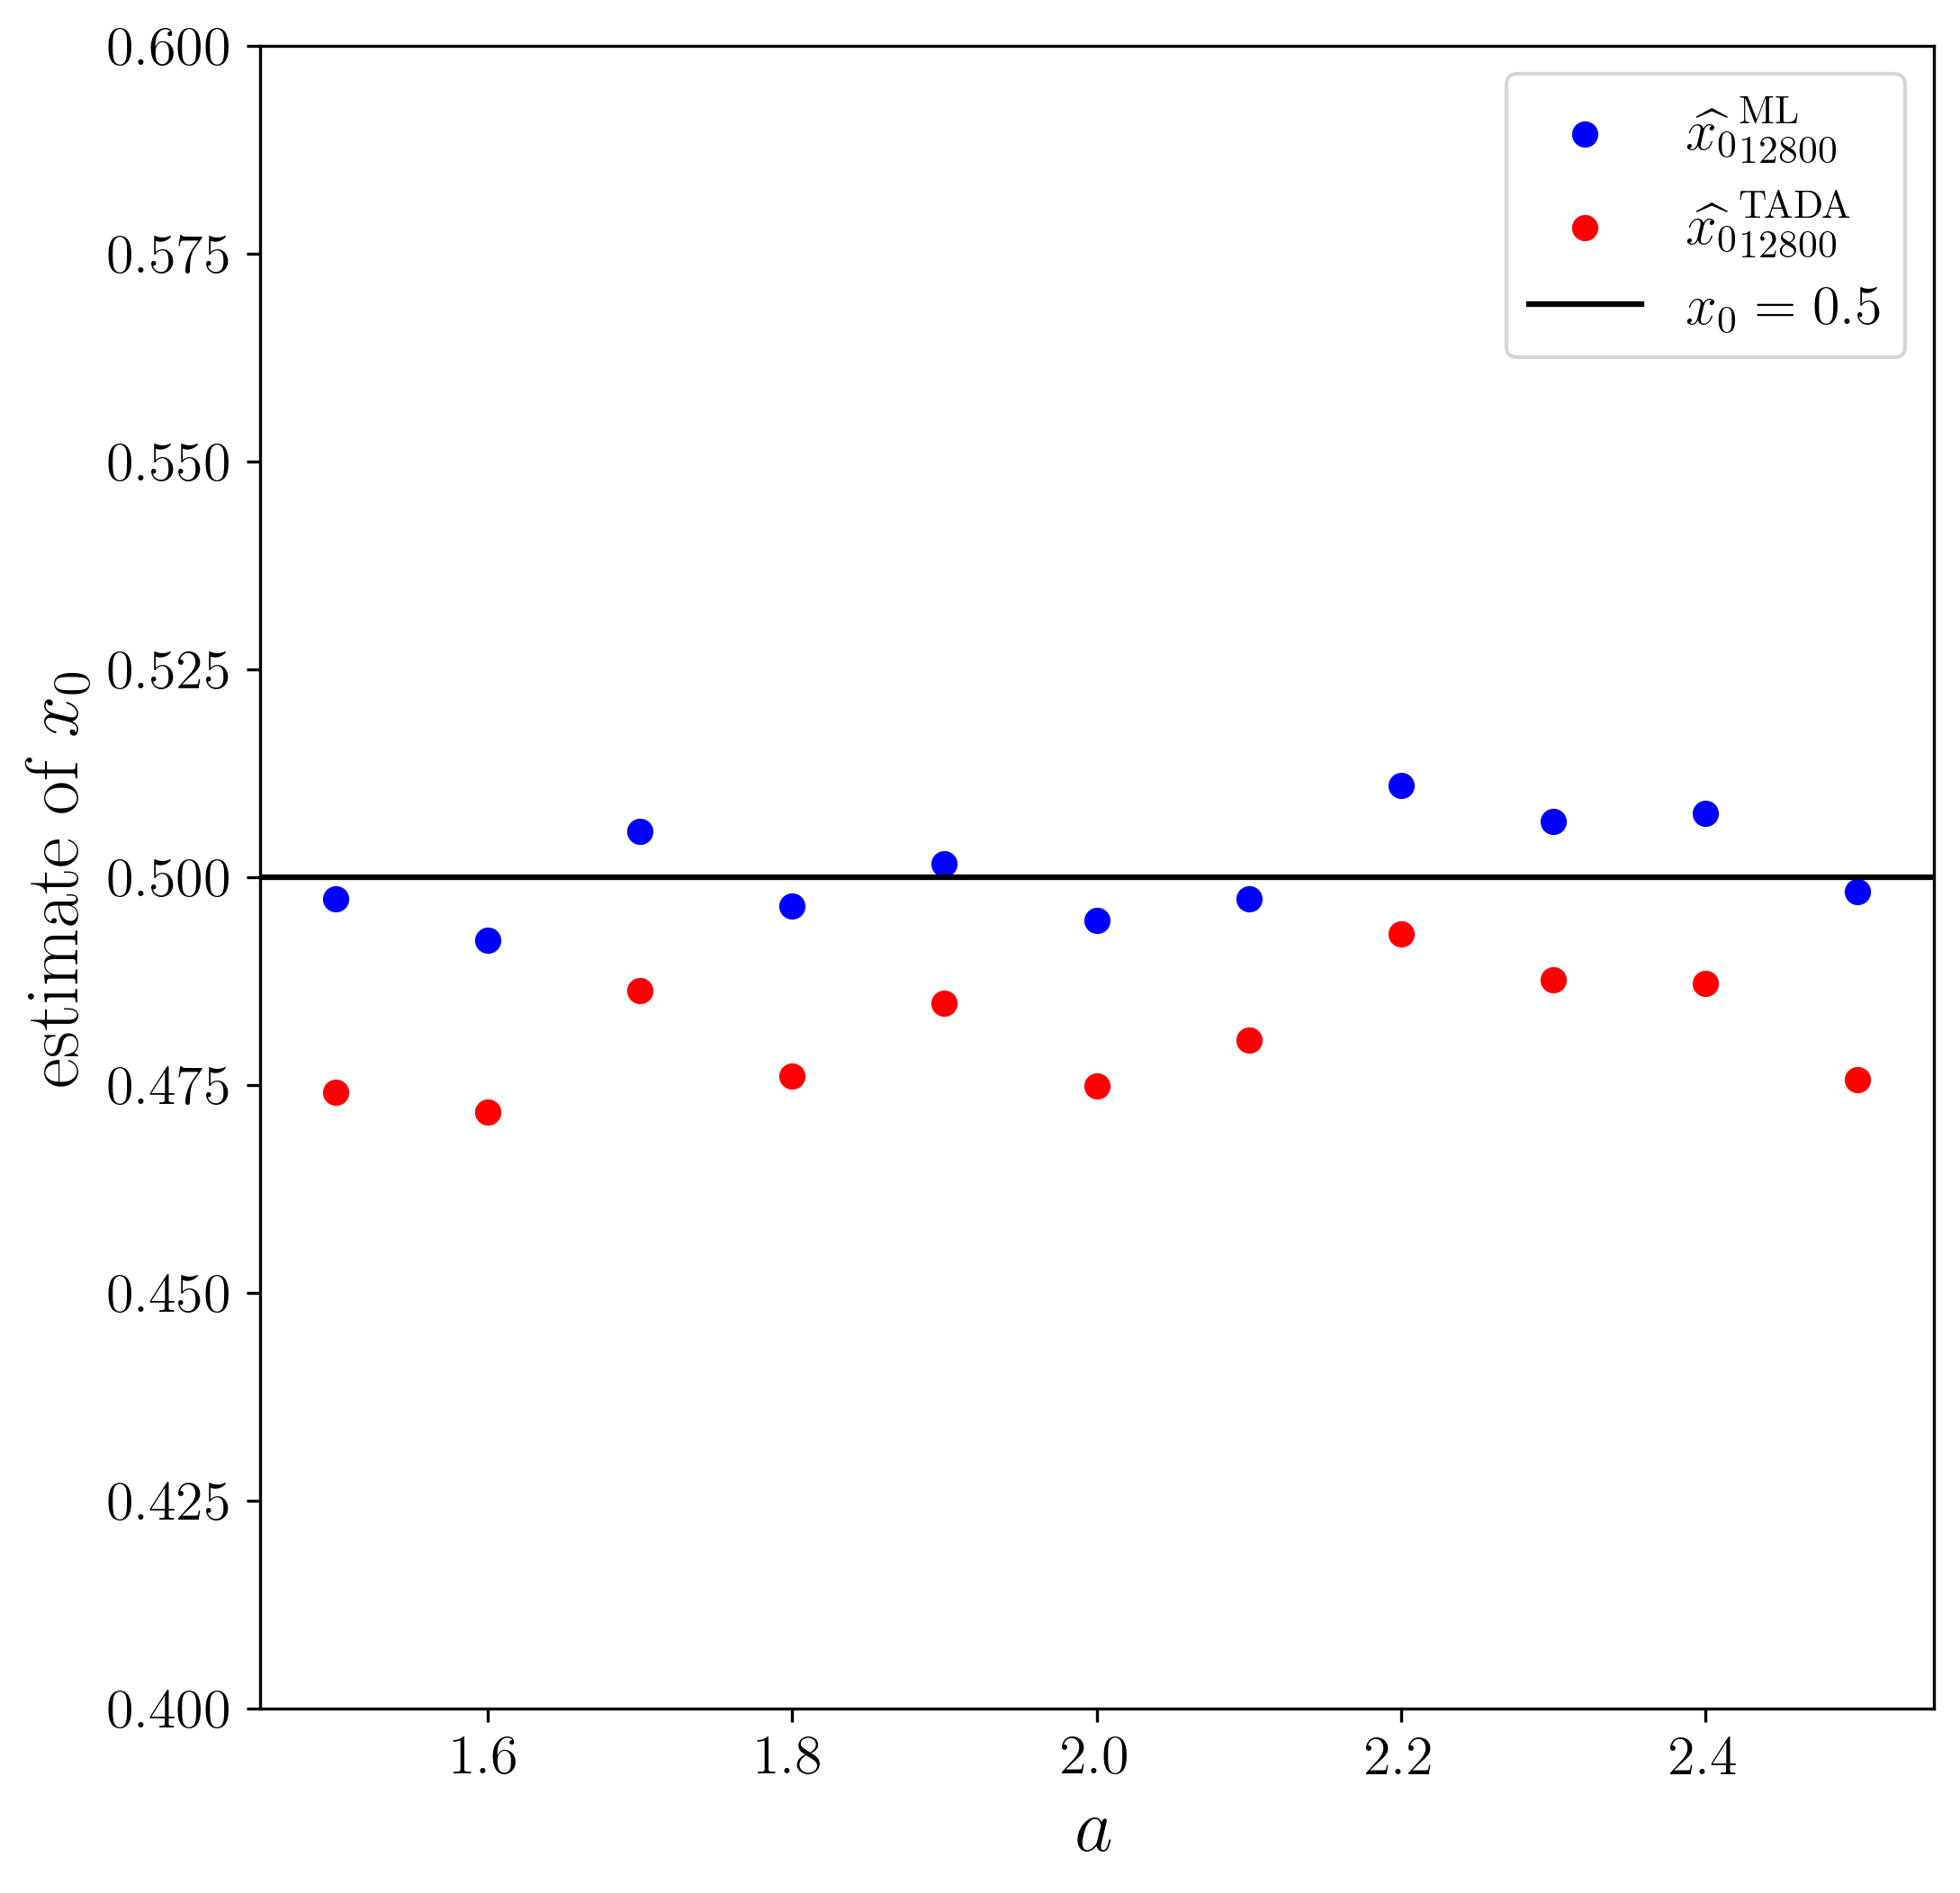

In [14]:
plot_param_estimate(
    paras_true, paras_mle, paras_tada,
    param_idx=3, param_name=r"x_0",
    swept_idx=2, swept_name=r"a",
    num_data_list=num_data_list,
    horizontal_line=paras_true[-2, 0, 3],
    xlim=(1.45, 2.55), ylim=(0.4, 0.6),
)